In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("bhaveshkumars/release-in-the-wild")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'release-in-the-wild' dataset.
Path to dataset files: /kaggle/input/release-in-the-wild


In [ ]:
import os
import torch
import torchaudio
from tqdm import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ============================
# 1. Dataset Class
# ============================
class AudioDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.file_paths = []
        self.labels = []
        self.transform = transform

        for filepath in os.listdir(real_dir):
            if filepath.endswith('.wav'):
                self.file_paths.append(os.path.join(real_dir, filepath))
                self.labels.append(0)  # Real = 0

        for filepath in os.listdir(fake_dir):
            if filepath.endswith('.wav'):
                self.file_paths.append(os.path.join(fake_dir, filepath))
                self.labels.append(1)  # Fake = 1

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(audio_path)

        # Ensure 3 sec length
        target_len = sample_rate * 3
        if waveform.shape[1] > target_len:
            waveform = waveform[:, :target_len]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.shape[1]))

        # Extract MFCC
        mfcc = torchaudio.transforms.MFCC(sample_rate=sample_rate, n_mfcc=40)(waveform)
        mfcc = mfcc.mean(dim=-1).squeeze()

        return mfcc, label


# ============================
# 2. Model Definition
# ============================
class ANNModel(nn.Module):
    def __init__(self, input_dim):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        return torch.sigmoid(self.out(x)).squeeze()


# ============================
# 3. Training Function
# ============================
def standardize_dataset(dataset):
    X, y = [], []
    for feature, label in dataset:
        X.append(feature.numpy())
        y.append(label)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)

# ==================================================
#Adam optimizer + Backpropagation (training algorithm)
# ==================================================
def train_model(model, train_loader, val_loader, num_epochs=20, patience=5):
    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    best_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss, train_true, train_pred = 0, [], []

        for X_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch.float())
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

            predicted = (y_pred >= 0.5).int()
            train_true.extend(y_batch.numpy())
            train_pred.extend(predicted.numpy())

        avg_train_loss = train_loss / len(train_loader)
        train_acc = accuracy_score(train_true, train_pred)

        # Validation
        # =======================================
        #Early stopping (regularization algorithm)
        # =======================================
        model.eval()
        val_loss, val_true, val_pred = 0, [], []
        for X_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
            with torch.no_grad():
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch.float())
                val_loss += loss.item()
                predicted = (y_pred >= 0.5).int()
                val_true.extend(y_batch.numpy())
                val_pred.extend(predicted.numpy())

        avg_val_loss = val_loss / len(val_loader)
        val_acc = accuracy_score(val_true, val_pred)

        print(f"\nEpoch {epoch+1:02d} | "
              f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early stopping
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), "best_model.pth")
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered!")
                break


# ============================
# 4. Main Training
# ============================
if __name__ == "__main__":
    # Paths
    train_real = path + '/release_in_the_wild/train/real'
    train_fake = path + '/release_in_the_wild/train/fake'
    val_real = path + '/release_in_the_wild/val/real'
    val_fake = path + '/release_in_the_wild/val/fake'

    # Datasets
    train_dataset = AudioDataset(train_real, train_fake)
    val_dataset = AudioDataset(val_real, val_fake)

    # Standardize
    X_train, y_train = standardize_dataset(train_dataset)
    X_val, y_val = standardize_dataset(val_dataset)

    # Dataloaders
    train_loader = DataLoader(torch.utils.data.TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(torch.utils.data.TensorDataset(X_val, y_val), batch_size=32)

    # Model
    input_dim = X_train.shape[1]
    model = ANNModel(input_dim)

    # Train
    train_model(model, train_loader, val_loader, num_epochs=10)

Epoch 1/10 [Val]: 100%|██████████| 199/199 [00:00<00:00, 1479.70it/s]



Epoch 01 | Train Loss: 0.1277 | Train Acc: 0.9624 | Val Loss: 0.0406 | Val Acc: 0.9879


Epoch 2/10 [Val]: 100%|██████████| 199/199 [00:00<00:00, 1016.42it/s]



Epoch 02 | Train Loss: 0.0705 | Train Acc: 0.9772 | Val Loss: 0.0355 | Val Acc: 0.9904


Epoch 3/10 [Val]: 100%|██████████| 199/199 [00:00<00:00, 1418.31it/s]


...


Epoch 08 | Train Loss: 0.0405 | Train Acc: 0.9864 | Val Loss: 0.0242 | Val Acc: 0.9934


Epoch 9/10 [Val]: 100%|██████████| 199/199 [00:00<00:00, 994.67it/s]



Epoch 09 | Train Loss: 0.0414 | Train Acc: 0.9864 | Val Loss: 0.0261 | Val Acc: 0.9931


Epoch 10/10 [Val]: 100%|██████████| 199/199 [00:00<00:00, 1383.66it/s]


Epoch 10 | Train Loss: 0.0380 | Train Acc: 0.9876 | Val Loss: 0.0228 | Val Acc: 0.9937


Evaluating Test: 100%|██████████| 100/100 [00:00<00:00, 1569.21it/s]



Test Classification Report:

              precision    recall  f1-score   support

        Real       0.99      1.00      1.00      1997
        Fake       1.00      0.99      0.99      1182

    accuracy                           0.99      3179
   macro avg       1.00      0.99      0.99      3179
weighted avg       0.99      0.99      0.99      3179



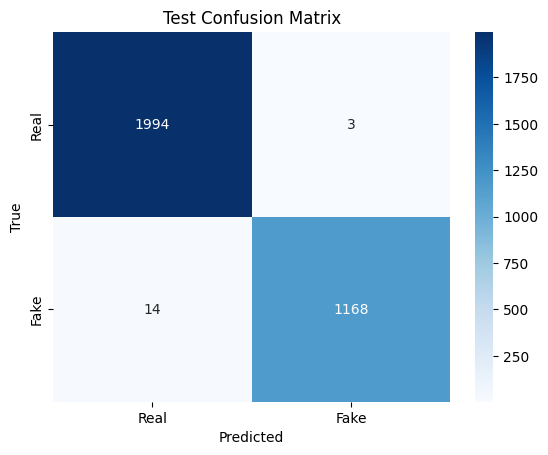

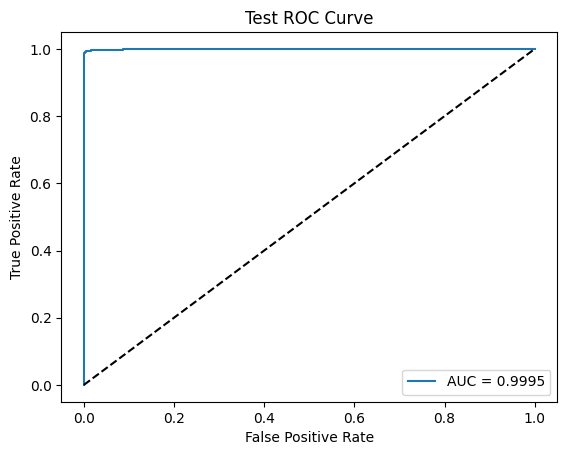

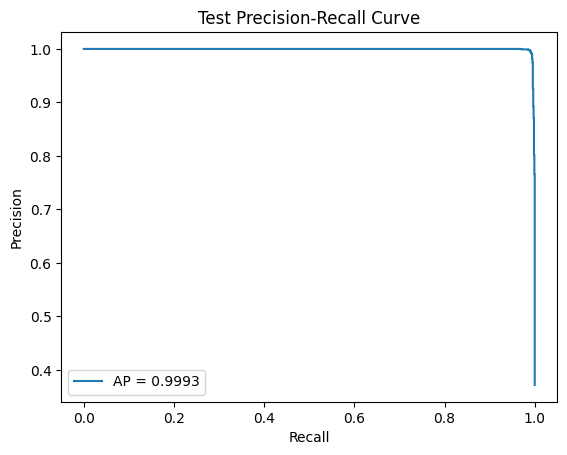

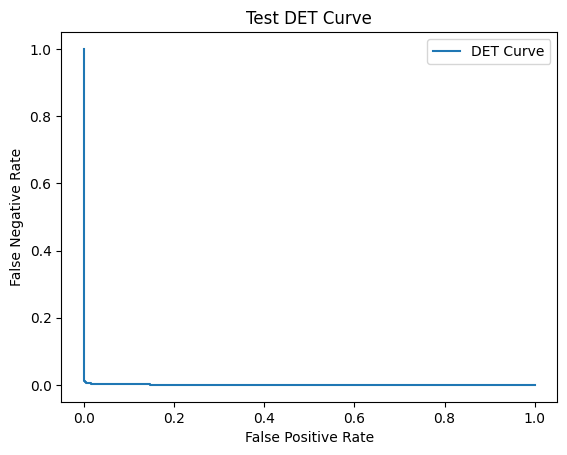

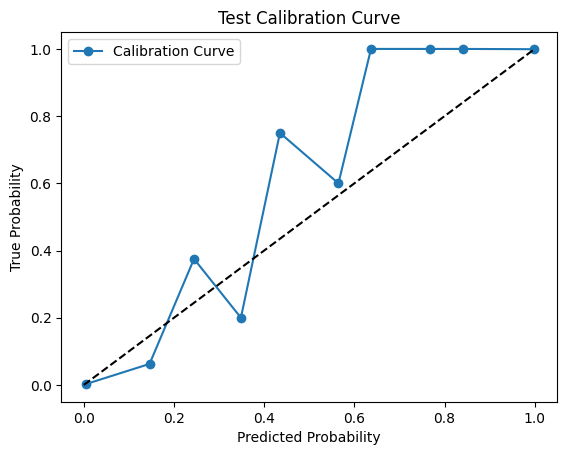

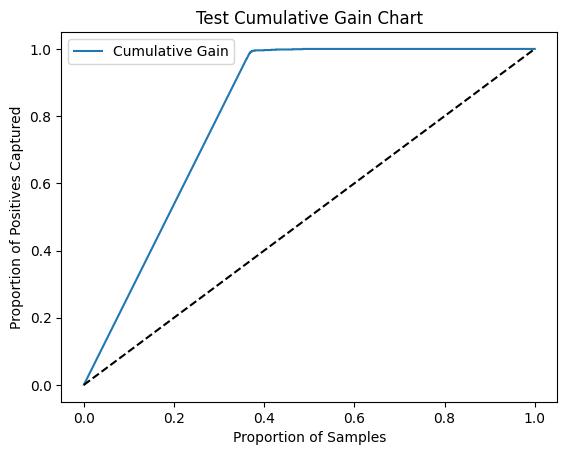

Test EER: 0.57%
Test AUC: 0.9995
Test min t-DCF: 0.0057
Test Average Precision (AP): 0.9993
Test Brier Score: 0.0046
Test KS Statistic: 0.9887 (p=0.0000)

================ Final Metrics ================
EER: 0.5715
AUC: 0.9995
min_tDCF: 0.0057
AP: 0.9993
Brier: 0.0046
KS: 0.9887


In [ ]:
import os
import torch
import torchaudio
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score, brier_score_loss
)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm


# ============================================================
# 1) DATASET class
#    Algorithm: MFCC feature extraction (signal processing)
#    Preprocessing: fixed-length padding/truncation (3 seconds)
#    Task: Build (feature, label) pairs from Real(0)/Fake(1) folders
# ============================================================
class AudioDataset(Dataset):
    def __init__(self, real_dir, fake_dir, transform=None):
        self.file_paths = []
        self.labels = []
        self.transform = transform

        for filepath in os.listdir(real_dir):
            if filepath.endswith('.wav'):
                self.file_paths.append(os.path.join(real_dir, filepath))
                self.labels.append(0)

        for filepath in os.listdir(fake_dir):
            if filepath.endswith('.wav'):
                self.file_paths.append(os.path.join(fake_dir, filepath))
                self.labels.append(1)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        audio_path = self.file_paths[idx]
        label = self.labels[idx]
        waveform, sample_rate = torchaudio.load(audio_path)

        target_len = sample_rate * 3
        if waveform.shape[1] > target_len:
            waveform = waveform[:, :target_len]
        else:
            waveform = torch.nn.functional.pad(waveform, (0, target_len - waveform.shape[1]))

        mfcc = torchaudio.transforms.MFCC(sample_rate=sample_rate, n_mfcc=40)(waveform)
        mfcc = mfcc.mean(dim=-1).squeeze()
        return mfcc, label


# ==================================================================
# 2) MODEL
#    Algorithm: Feed-forward Artificial Neural Network (classifier)
#    Components: Linear layers + BatchNorm + ReLU + Dropout + Sigmoid
#    Output: Probability of "Fake" (binary classification)
# ==================================================================
class ANNModel(nn.Module):
    def __init__(self, input_dim):
        super(ANNModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.dropout2 = nn.Dropout(0.3)

        self.out = nn.Linear(64, 1)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        return torch.sigmoid(self.out(x)).squeeze()


# ====================================================================================
# 3) HELPERS
#    Algorithm: Z-score Standardization (feature scaling with StandardScaler)
#    Metric algorithms:
#      - EER (Equal Error Rate) from ROC (fpr/tpr)
#      - min t-DCF (tandem Detection Cost Function) over operating points
# ====================================================================================
def standardize_dataset(dataset):
    X, y = [], []
    for feature, label in dataset:
        X.append(feature.numpy())
        y.append(label)
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y)


def compute_eer(fpr, tpr):
    fnr = 1 - tpr
    abs_diffs = np.abs(fpr - fnr)
    idx = np.argmin(abs_diffs)
    eer = (fpr[idx] + fnr[idx]) / 2
    return eer * 100


def compute_min_tDCF(fpr, fnr, Cmiss=1, Cfa=1, Ptar=0.5):
    tDCF = Cmiss * Ptar * fnr + Cfa * (1 - Ptar) * fpr
    return np.min(tDCF)


# ======================================================================================================
# 4) EVALUATION
#    Algorithms used here (threshold-free & thresholded performance analysis):
#      - Classification report (precision/recall/F1)
#      - Confusion Matrix
#      - ROC Curve + AUC (rank quality)
#      - EER (Equal Error Rate) from ROC
#      - min t-DCF (biometric cost metric)
#      - Precision–Recall Curve + Average Precision (AP)
#      - DET Curve (FPR vs FNR)
#      - Calibration Curve + Brier Score (probability calibration)
#      - KS (Kolmogorov–Smirnov) test for score separation
#      - Cumulative Gain chart (top-k targeting effectiveness)
#    Note: Adam optimizer + Backpropagation are part of the TRAINING loop (not included in this file).
# ======================================================================================================
def evaluate_model(model, test_loader, split_name="Test"):
    model.load_state_dict(torch.load("best_model.pth"))
    model.eval()
    y_true, y_pred, y_scores = [], [], []

    for X_batch, y_batch in tqdm(test_loader, desc=f"Evaluating {split_name}"):
        with torch.no_grad():
            outputs = model(X_batch).cpu().numpy()
            preds = (outputs >= 0.5).astype(int)

            y_true.extend(y_batch.numpy())
            y_pred.extend(preds)
            y_scores.extend(outputs)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_scores = np.array(y_scores)

    # -------------------------
    # Basic Metrics
    # -------------------------
    print(f"\n{split_name} Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Real", "Fake"], yticklabels=["Real", "Fake"])
    plt.title(f"{split_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # -------------------------
    # ROC & AUC
    # -------------------------
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    auc_score = roc_auc_score(y_true, y_scores)
    eer = compute_eer(fpr, tpr)
    min_tDCF = compute_min_tDCF(fpr, 1 - tpr)

    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split_name} ROC Curve")
    plt.legend()
    plt.show()

    # -------------------------
    # Precision-Recall Curve
    # -------------------------
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    ap = average_precision_score(y_true, y_scores)

    plt.plot(recall, precision, label=f"AP = {ap:.4f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{split_name} Precision-Recall Curve")
    plt.legend()
    plt.show()

    # -------------------------
    # DET Curve (FPR vs FNR)
    # -------------------------
    fnr = 1 - tpr
    plt.plot(fpr, fnr, label="DET Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("False Negative Rate")
    plt.title(f"{split_name} DET Curve")
    plt.legend()
    plt.show()

    # -------------------------
    # Calibration Curve
    # -------------------------
    from sklearn.calibration import calibration_curve
    prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
    plt.plot(prob_pred, prob_true, marker='o', label="Calibration Curve")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("Predicted Probability")
    plt.ylabel("True Probability")
    plt.title(f"{split_name} Calibration Curve")
    plt.legend()
    plt.show()

    # Brier Score
    brier = brier_score_loss(y_true, y_scores)

    # -------------------------
    # KS Statistic (separation)
    # -------------------------
    real_scores = y_scores[y_true == 0]
    fake_scores = y_scores[y_true == 1]
    from scipy.stats import ks_2samp
    ks_stat, ks_p = ks_2samp(real_scores, fake_scores)

    # -------------------------
    # Cumulative Gain / Lift Chart
    # -------------------------
    sorted_indices = np.argsort(-y_scores)
    y_sorted = y_true[sorted_indices]
    gains = np.cumsum(y_sorted) / np.sum(y_sorted)
    perc = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

    plt.plot(perc, gains, label="Cumulative Gain")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("Proportion of Samples")
    plt.ylabel("Proportion of Positives Captured")
    plt.title(f"{split_name} Cumulative Gain Chart")
    plt.legend()
    plt.show()

    # -------------------------
    # Final Metrics Summary
    # -------------------------
    print(f"{split_name} EER: {eer:.2f}%")
    print(f"{split_name} AUC: {auc_score:.4f}")
    print(f"{split_name} min t-DCF: {min_tDCF:.4f}")
    print(f"{split_name} Average Precision (AP): {ap:.4f}")
    print(f"{split_name} Brier Score: {brier:.4f}")
    print(f"{split_name} KS Statistic: {ks_stat:.4f} (p={ks_p:.4f})")

    return {
        "EER": eer,
        "AUC": auc_score,
        "min_tDCF": min_tDCF,
        "AP": ap,
        "Brier": brier,
        "KS": ks_stat
    }


# ============================
# 5. Main Testing
# ============================
if __name__ == "__main__":
    test_real = path + '/release_in_the_wild/test/real'
    test_fake = path + '/release_in_the_wild/test/fake'

    test_dataset = AudioDataset(test_real, test_fake)
    X_test, y_test = standardize_dataset(test_dataset)
    test_loader = DataLoader(torch.utils.data.TensorDataset(X_test, y_test), batch_size=32)

    model = ANNModel(input_dim=X_test.shape[1])
    metrics = evaluate_model(model, test_loader, "Test")

    print("\n================ Final Metrics ================")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")